In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set(style='darkgrid', palette='Dark2')
warnings.filterwarnings('ignore')
from sklearn.metrics import  classification_report,confusion_matrix

In [2]:
data = pd.read_csv('Titanic.csv')
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
data = data.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


<Axes: xlabel='Sex', ylabel='count'>

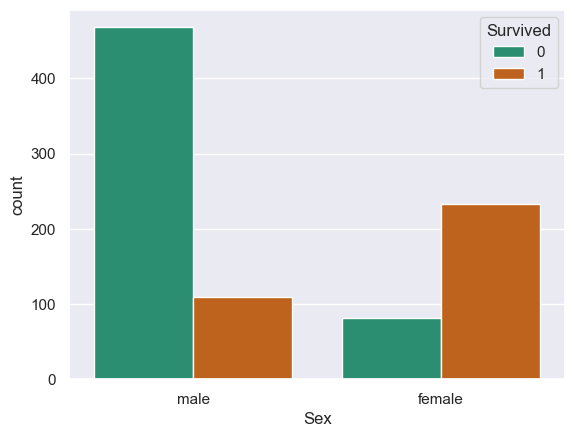

In [4]:
sns.countplot(x=data.Sex , hue = data.Survived)

<Axes: xlabel='Pclass', ylabel='count'>

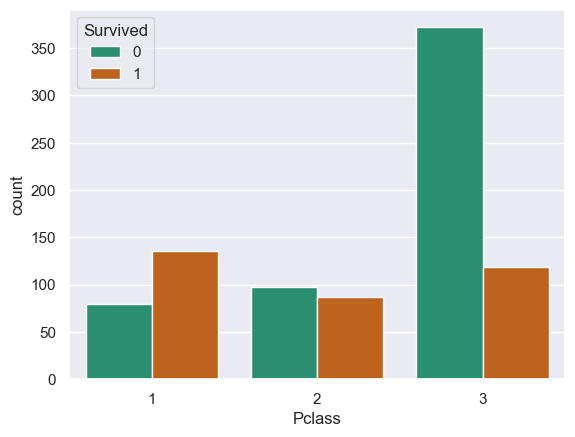

In [5]:
sns.countplot(x=data.Pclass , hue = data.Survived)

<Axes: xlabel='SibSp', ylabel='count'>

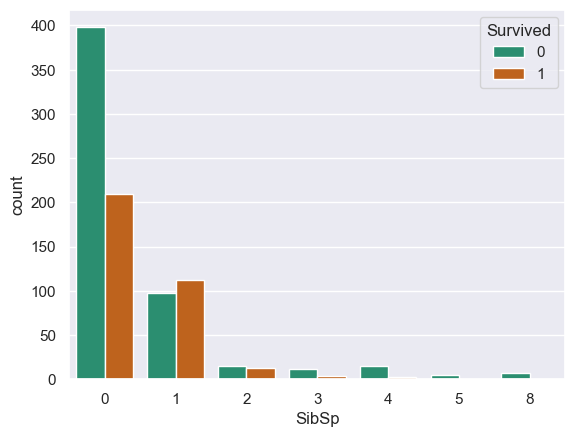

In [6]:
sns.countplot(x=data.SibSp , hue = data.Survived)

In [7]:
data=data.dropna()

In [8]:
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C
10,1,3,female,4.0,1,1,16.7000,S


In [9]:
data.describe(include='all')


Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data['Age'] = data['Age'].clip(lower, upper)

# For Fare
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data['Fare'] = data['Fare'].clip(lower, upper)


data.info()
main_data=data

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


In [10]:
sex=pd.get_dummies(data['Sex'],drop_first=True).astype(int)
sex

emb=pd.get_dummies(data['Embarked'] , drop_first=True).astype('int64')
emb

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
885,1,0
886,0,1
887,0,1
889,0,0


In [11]:
data['embQ']=emb['Q']
data['embS']=emb['S']
data['male']=sex['male']

data.drop(['Sex' , 'Embarked'] , axis=1,inplace=True)

data.dtypes

Survived      int64
Pclass        int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
embQ          int64
embS          int64
male          int64
dtype: object

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])

In [13]:

data.Family = data.Parch + data.SibSp
print(data.Fare)

0       7.250
1      70.425
2       7.925
3      53.100
4       8.050
        ...  
885    29.125
886    13.000
887    30.000
889    30.000
890     7.750
Name: Fare, Length: 712, dtype: float64


In [14]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(class_weight='balanced')
from sklearn.model_selection import train_test_split , cross_val_score
x_train,x_test , y_train , y_test = train_test_split(data.drop(['Survived','Parch','SibSp'],axis=1) , data.Survived , test_size=0.2)

x_train[['Age', 'Fare']] = scaler.fit_transform(x_train[['Age', 'Fare']])
x_test[['Age', 'Fare']] = scaler.transform(x_test[['Age', 'Fare']])

In [15]:
lg.fit(x_train,y_train)
print(np.mean(cross_val_score(lg, x_train, y_train, cv=5)))


0.8049371215649744


In [16]:
confusion_matrix(y_test , lg.predict(x_test))

array([[65, 21],
       [11, 46]])

In [17]:
lg.fit(x_train, y_train)
pred = lg.predict(x_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy :", accuracy)

Accuracy : 0.7762237762237763


In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
   
)

dt.fit(x_train,y_train)
pred = dt.predict(x_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy :", accuracy)

Accuracy : 0.7832167832167832


In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
pred = knn.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print("Accuracy :", accuracy)
confusion_matrix(y_test , knn.predict(x_test))

Accuracy : 0.8111888111888111


array([[77,  9],
       [18, 39]])

In [20]:
from sklearn.svm import SVC

svc = SVC(
    kernel='linear',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svc.fit(x_train, y_train)
pred = svc.predict(x_test)

accuracy = accuracy_score(y_test, pred)
print("SVC Accuracy :", accuracy)

print(confusion_matrix(y_test, pred))


SVC Accuracy : 0.7482517482517482
[[70 16]
 [20 37]]


In [21]:
from sklearn.linear_model import Perceptron
svc = Perceptron()

svc.fit(x_train, y_train)
pred = svc.predict(x_test)

accuracy = accuracy_score(y_test, pred)
print("SVC Accuracy :", accuracy)

print(confusion_matrix(y_test, pred))


SVC Accuracy : 0.7832167832167832
[[71 15]
 [16 41]]
